In [1]:
import networkx as nx
import os
import sys
sys.path.append("..")
import pandas as pd
import tqdm
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
from src.datapreprocess import generate_summary
import matplotlib.pyplot as plt

In [ ]:
df_argcounts = pd.read_csv(r"D:\A.baumannii\data\acquired_resistance_genes.csv", index_col=0,
                           dtype={"Genome_ID": str})
df_mge = pd.read_csv(r"D:\A.baumannii\data\MGE_count_AB.csv", index_col=0,
                        dtype={"Genome_ID": str})
df_mge = df_mge.groupby("Genome_ID").sum()    
df_summary = pd.read_csv(r"D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv", 
                      dtype={"Genome_ID": str}, index_col=0)
print(df_summary)
print(df_mge)

                 Aminoglycoside  Beta-lactam  Fosfomycin  Quinolone  \
Genome_ID                                                             
GCA_000173395.1               0            0           0          0   
GCA_000226275.2               1            1           0          0   
GCA_000241705.2               1            0           0          0   
GCA_000241725.2               1            1           0          0   
GCA_000278605.1               1            1           0          0   
...                         ...          ...         ...        ...   
GCA_964331915.1               1            1           0          0   
GCA_964331925.1               1            1           0          0   
GCA_964331935.1               1            1           0          0   
GCA_964331945.1               1            1           0          0   
GCA_964331965.1               1            1           0          0   

                 Diaminopyrimidine  Peptide  Nucleoside  Tetracycline  \
Gen

In [3]:
genome2use = list(set(df_argcounts.index) & set(df_mge.index))

df_argmge = pd.concat([df_argcounts.loc[genome2use, :], df_mge.loc[genome2use, :]], axis=1)

In [ ]:
df_argcounts = pd.read_csv(r"D:\A.baumannii\data\acquired_resistance_genes.csv", index_col=0,
                           dtype={"Genome_ID": str})
df_mge = pd.read_csv(r"D:\A.baumannii\data\MGE_count_AB.csv", index_col=0,
                        dtype={"Genome_ID": str})
df_mge = df_mge.groupby("Genome_ID").sum() 
# 选择特定年份
index2chose = df_summary[(df_summary['year'] < 2000)]
index2chose = list(set(index2chose.index) & set(genome2use))
df_argmge = df_argmge.loc[list(index2chose), :]
df_argmge = df_argmge.loc[:, df_argmge.sum() > 0]
print(df_argmge.shape)
aj_matrix = np.zeros((df_argmge.shape[1], df_argmge.shape[1]))
for i in tqdm.tqdm(range(df_argmge.shape[1])):
    for j in range(i+1, df_argmge.shape[1]):
        r, p = spearmanr(df_argmge.iloc[:, i], df_argmge.iloc[:, j])
        if r > 0.4:
            aj_matrix[i, j] = r
            aj_matrix[j, i] = r

df_aj = pd.DataFrame(aj_matrix, index=df_argmge.columns, columns=df_argmge.columns)
G = nx.from_pandas_adjacency(df_aj)

(103, 59)


100%|██████████| 59/59 [00:00<00:00, 80.67it/s]


([], [])

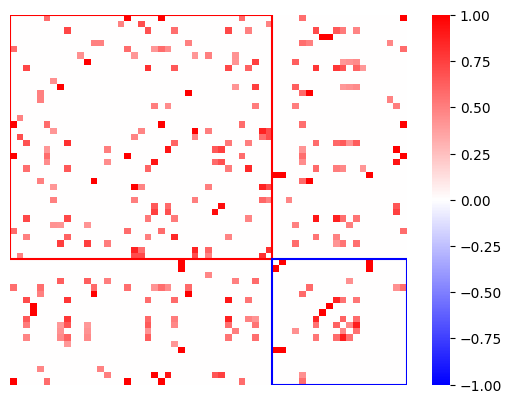

In [5]:
arg_num = df_argcounts.loc[index2chose, 
                           df_argcounts.loc[index2chose, :].sum() > 0].shape[1]
mge_num = df_mge.loc[index2chose, 
                     df_mge.loc[index2chose, :].sum() > 0].shape[1]
sns.heatmap(df_aj, vmin=-1, vmax=1,
            cmap='bwr')
# 在heatmap中框选除arg与mge
plt.plot([0, 0, arg_num, arg_num, 0], [0, arg_num, arg_num, 0, 0], color='red')
plt.plot([arg_num, arg_num, mge_num + arg_num, mge_num + arg_num, arg_num], 
         [arg_num, mge_num + arg_num, mge_num + arg_num, arg_num, arg_num], color='blue')
plt.xticks([])
plt.yticks([])

In [6]:
print(arg_num)
print(mge_num)

39
20


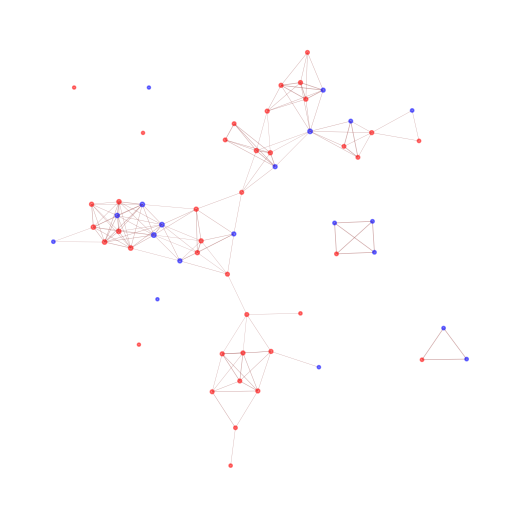

In [ ]:
# Plot G

Nodes_color = []
for i, node in enumerate(G.nodes):
    if i < arg_num:
        Nodes_color.append('red')
    else:
        Nodes_color.append('blue')

edge_color = []
edge_width = []
for e in G.edges(data=True):
    if e[2]['weight'] < 0:
        edge_color.append('blue')
    else:
        edge_color.append((163 / 255, 84 / 255, 83 / 255))
    edge_width.append(np.abs(e[2]['weight']) * 0.5)


pos = nx.nx_agraph.graphviz_layout(G, root=0)
Nodes_size = [(5 + d * 0.5) for d in dict(G.degree).values()]
plt.figure(figsize=(5, 5))
nx.draw(G,
        pos=pos,
        node_color=Nodes_color, node_size=Nodes_size, 
        edge_color=edge_color,
        width=edge_width,
        alpha=0.5)
plt.savefig('network00.pdf',dpi=600,format='pdf')

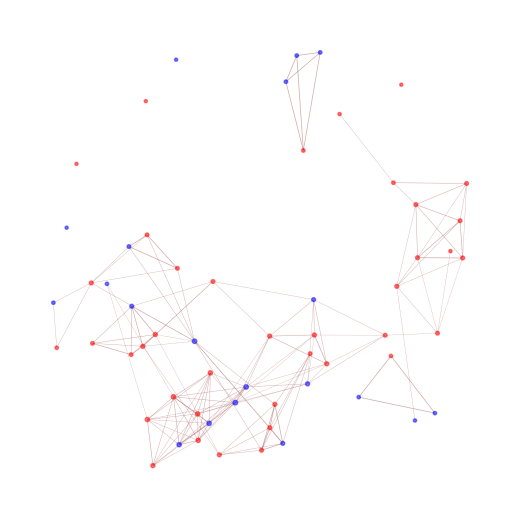

In [ ]:
pos = nx.layout.spring_layout(G, k=0.5)
plt.figure(figsize=(5, 5))

nx.draw(G,
        pos=pos,
        node_color=Nodes_color, node_size=Nodes_size, 
        edge_color=edge_color,
        width=edge_width,
        alpha=0.5)
plt.savefig('network00-1.pdf',dpi=600,format='pdf')

Text(0.5, 0, 'Degree')

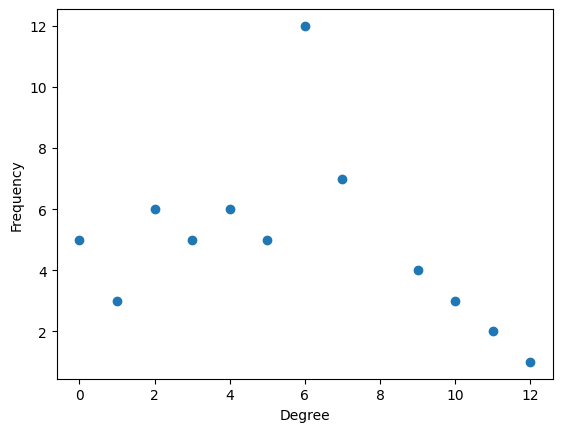

In [9]:
from collections import Counter
import matplotlib.pyplot as plt
degree_distribution = Counter(dict(G.degree()).values())
plt.plot(list(degree_distribution.keys()), list(degree_distribution.values()), 'o')
# plt.yscale('log')
plt.ylabel('Frequency')
plt.xlabel('Degree')

Text(0, 0.5, 'MGE')

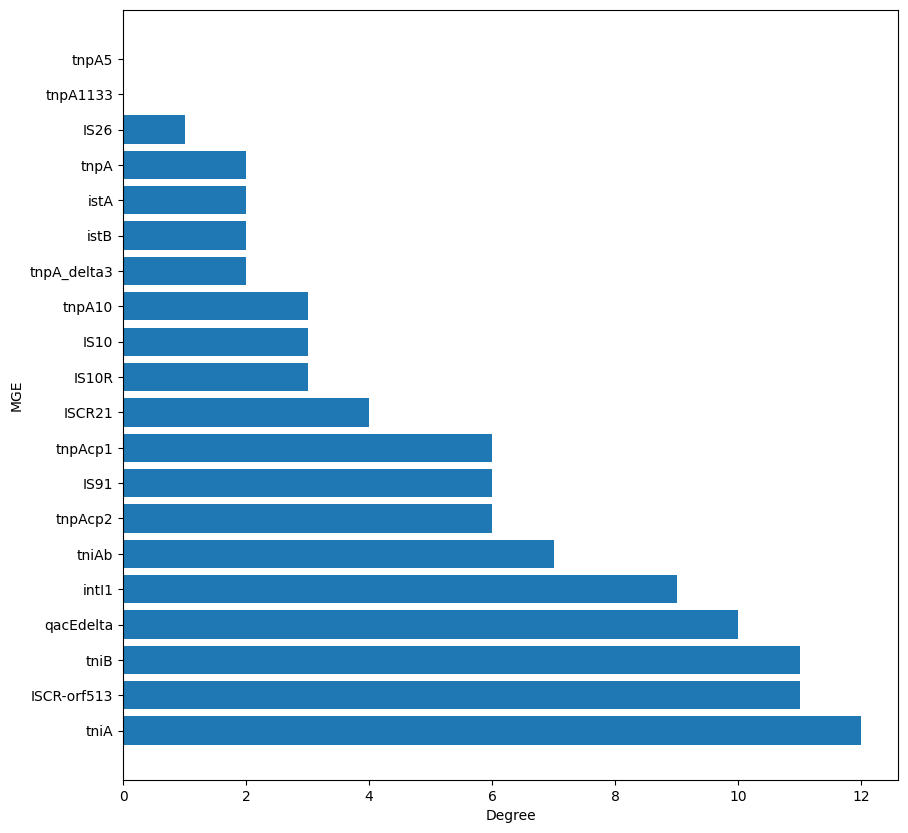

In [10]:
# 输出度最大的node
# MGE节点按照度分布排序
all_degree = dict(G.degree())
mge_degree = {k: v for k, v in all_degree.items() if k in list(df_mge.columns)}
mge_degrees = pd.Series(mge_degree).sort_values(ascending=False)
# 输出度最大的node
# 绘制barh plot
plt.figure(figsize=(10, 10))
plt.barh(mge_degrees.iloc[:20].index, mge_degrees.iloc[:20].values)
plt.xlabel("Degree")
plt.ylabel("MGE")


In [11]:
# 输出betweenness最大的node
max(nx.betweenness_centrality(G).items(), key=lambda x: x[1])

('OXA-23', 0.3049001814882033)